In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
# Define dataset paths
TRAIN_DIR = '../data/raw/chest_xray/chest_xray/train'
VAL_DIR   = '../data/raw/chest_xray/chest_xray/val'
TEST_DIR  = '../data/raw/chest_xray/chest_xray/test'

# Count images in each split
for split, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    normal    = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    print(f"{split:6} -> NORMAL: {normal:4d} | PNEUMONIA: {pneumonia:4d} | Total: {normal+pneumonia}")

Train  -> NORMAL: 1342 | PNEUMONIA: 3876 | Total: 5218
Val    -> NORMAL:    9 | PNEUMONIA:    9 | Total: 18
Test   -> NORMAL:  234 | PNEUMONIA:  390 | Total: 624


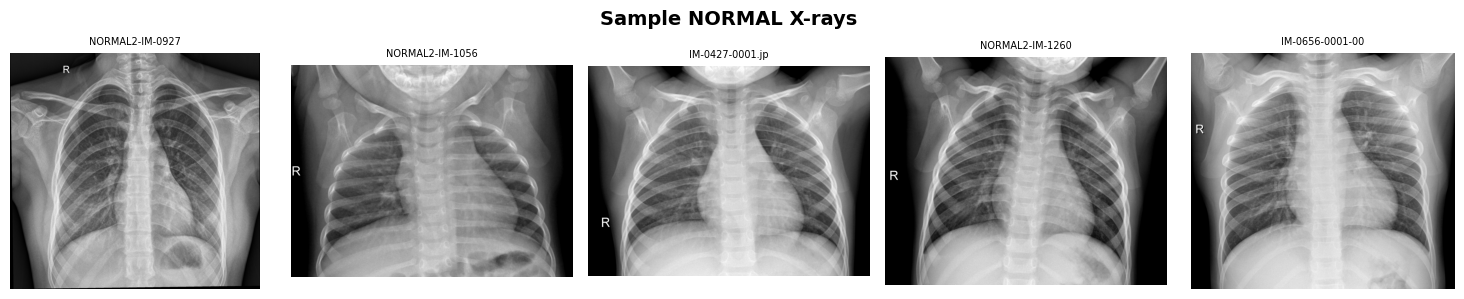

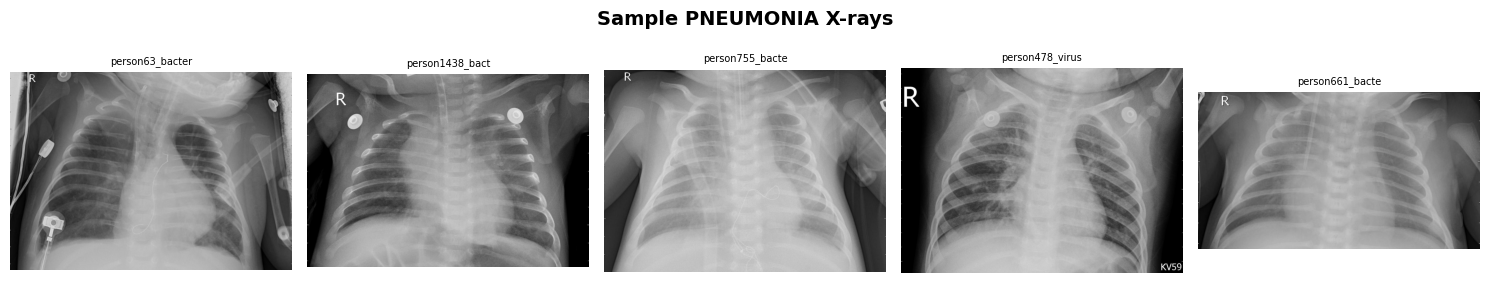

In [3]:
def show_sample_images(directory, label, num_images=5):
    images = os.listdir(directory)[:num_images]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    fig.suptitle(f'Sample {label} X-rays', fontsize=14, fontweight='bold')
    for i, img_name in enumerate(images):
        img_path = os.path.join(directory, img_name)
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(img_name[:15], fontsize=7)
    plt.tight_layout()
    plt.show()

show_sample_images(os.path.join(TRAIN_DIR, 'NORMAL'), 'NORMAL')
show_sample_images(os.path.join(TRAIN_DIR, 'PNEUMONIA'), 'PNEUMONIA')

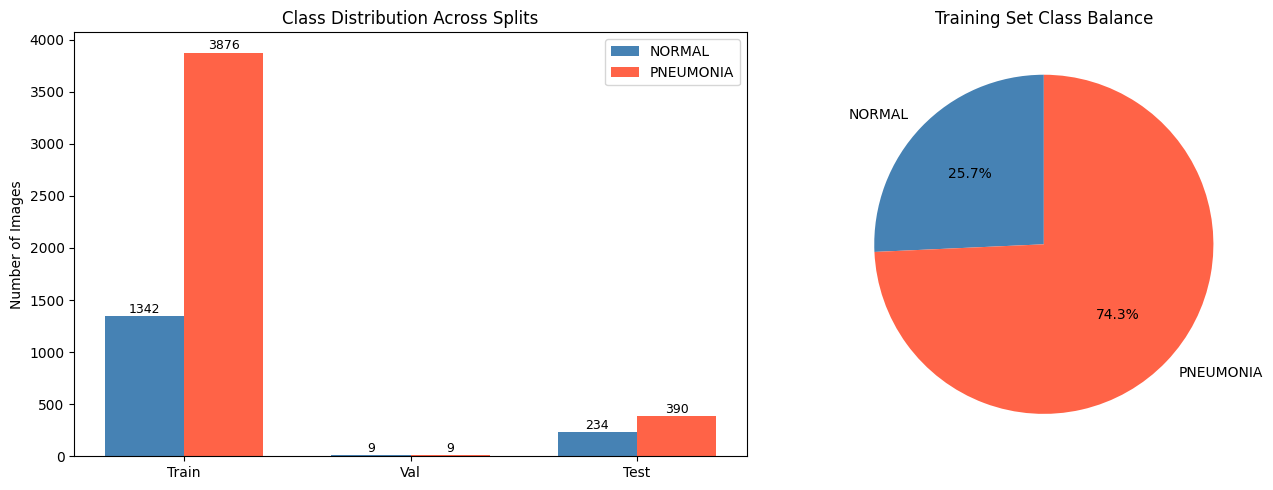

Class imbalance ratio: 2.89 :1 (Pneumonia:Normal)


In [4]:
# Class distribution chart
splits = ['Train', 'Val', 'Test']
normal_counts    = [1342, 9, 234]
pneumonia_counts = [3876, 9, 390]

x = np.arange(len(splits))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(x - width/2, normal_counts,    width, label='NORMAL',    color='steelblue')
axes[0].bar(x + width/2, pneumonia_counts, width, label='PNEUMONIA', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_title('Class Distribution Across Splits')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
for i, (n, p) in enumerate(zip(normal_counts, pneumonia_counts)):
    axes[0].text(i - width/2, n + 30, str(n), ha='center', fontsize=9)
    axes[0].text(i + width/2, p + 30, str(p), ha='center', fontsize=9)

# Pie chart for training set
axes[1].pie([1342, 3876],
            labels=['NORMAL', 'PNEUMONIA'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Training Set Class Balance')

plt.tight_layout()
plt.show()
print("Class imbalance ratio:", round(3876/1342, 2), ":1 (Pneumonia:Normal)")

In [5]:
# Analyze image dimensions
def get_image_stats(directory, num_samples=100):
    widths, heights = [], []
    all_images = []
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(directory, label)
        images = os.listdir(folder)[:num_samples]
        for img_name in images:
            if img_name.endswith('.jpeg') or img_name.endswith('.jpg'):
                all_images.append(os.path.join(folder, img_name))
    for img_path in all_images:
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    return widths, heights

widths, heights = get_image_stats(TRAIN_DIR)

print(f"Width  -> min: {min(widths)}  max: {max(widths)}  avg: {int(np.mean(widths))}")
print(f"Height -> min: {min(heights)}  max: {max(heights)}  avg: {int(np.mean(heights))}")
print(f"\nImages vary in size — we will resize all to 224x224 for the model")

Width  -> min: 384  max: 2566  avg: 1439
Height -> min: 127  max: 2663  avg: 1114

Images vary in size — we will resize all to 224x224 for the model
